# Speaker Recognition — FINN Accelerator Inference on KV260

Inference for the Speaker Recognition FINN MLP Fully Conected model
```

---
## 0. Imports and configuration

In [1]:
import os, sys, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# Define which model to use for the inference ('4-bits' or '8-bits')
MODEL_WIDTH = '8-bits'

# ── Paths ────────────────────────────────────────────────────────────────────
HERE          = Path('.')          # directory containing this notebook
BITFILE       = HERE / MODEL_WIDTH / 'bitfile' / 'finn-accel.bit'
DEPLOY_EXTRAS = HERE / MODEL_WIDTH / 'deploy_extras'

assert BITFILE.exists(),            f'Bitfile not found: {BITFILE}'
assert DEPLOY_EXTRAS.exists(),      f'deploy_extras/ not found'
assert (HERE / MODEL_WIDTH / 'driver.py').exists(), 'driver.py not found'

# ── Load metadata ────────────────────────────────────────────────────────────
with open(DEPLOY_EXTRAS / 'classes.json') as f:
    META = json.load(f)

CLASSES       = META['classes']
NUM_CLASSES   = META['num_classes']
USE_CHANNELS  = META['use_channels']
N_MFCC        = META['n_mfcc']
MFCC_FRAMES   = META['mfcc_frames']
HOP_LENGTH    = META['hop_length']
N_FFT         = META['n_fft']
SAMPLING_FREQ = META['sampling_freq']
INPUT_CHANNELS = 1 if USE_CHANNELS == 'I' else 2

scale_arr  = np.load(DEPLOY_EXTRAS / 'input_scale.npy')
INPUT_SCALE = float(scale_arr[0])
INPUT_ZP    = float(scale_arr[1])

print('── Deployment metadata ──────────────────────────')
print(f'  Classes      : {CLASSES}')
print(f'  N_MFCC       : {N_MFCC}   MFCC_FRAMES: {MFCC_FRAMES}')
print(f'  Channels     : {USE_CHANNELS} ({INPUT_CHANNELS} ch)')
print(f'  Input scale  : {INPUT_SCALE:.6f}   zero_point: {INPUT_ZP}')
print(f'  Sampling freq: {SAMPLING_FREQ} Hz')
print('─────────────────────────────────────────────────')

── Deployment metadata ──────────────────────────
  Classes      : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']
  N_MFCC       : 20   MFCC_FRAMES: 64
  Channels     : I (1 ch)
  Input scale  : 0.045657   zero_point: 0.0
  Sampling freq: 48000 Hz
─────────────────────────────────────────────────


---
## 1. Load the FINN accelerator overlay

In [2]:
# Add current directory to sys.path so driver.py is importable
sys.path.insert(0, str(HERE / MODEL_WIDTH))

from driver import FINNExampleOverlay

print(f'Loading bitstream: {BITFILE.name} …')
t0 = time.time()

# FINNExampleOverlay is the class generated by FINN for PYNQ targets.
# It wraps pynq.Overlay and exposes .execute() for inference.
accel = FINNExampleOverlay(
    bitfile_name       = str(BITFILE),
    platform           = 'zynq-iodma',
    io_shape_dict      = getattr(__import__('driver'), 'io_shape_dict', {}),
    runtime_weight_dir = str(HERE / 'runtime_weights'),  # always a string; driver handles non-existent dir
)

print(f'Overlay loaded in {time.time()-t0:.1f} s')

Loading bitstream: finn-accel.bit …


Overlay loaded in 2.5 s


In [ ]:
# ── Inspect the driver's IO shape dictionary ─────────────────────────────────
# Shows if the exact numpy shape and dtype the accelerator expects.

import driver as _drv
if hasattr(_drv, 'io_shape_dict'):
    io_dict = _drv.io_shape_dict
    print('IO shape dict from driver.py:')
    # Print raw — avoids json.dumps choking on FINN IntType objects
    for key, val in io_dict.items():
        print(f'  {key}:')
        if isinstance(val, dict):
            for k2, v2 in val.items():
                print(f'    {k2}: {v2}')
        else:
            print(f'    {val}')
else:
    print('io_shape_dict not exported by driver.py — inspecting accel attributes:')
    for attr in dir(accel):
        if 'shape' in attr.lower() or 'buf' in attr.lower() or 'dtype' in attr.lower():
            print(f'  accel.{attr} = {getattr(accel, attr, "?")}')  


IO shape dict from driver.py:
  idt:
    [INT8]
  odt:
    [INT24]
  ishape_normal:
    [(1, 1280)]
  oshape_normal:
    [(1, 10)]
  ishape_folded:
    [(1, 320, 4)]
  oshape_folded:
    [(1, 10, 1)]
  ishape_packed:
    [(1, 320, 4)]
  oshape_packed:
    [(1, 10, 3)]
  input_dma_name:
    ['idma0']
  output_dma_name:
    ['odma0']
  number_of_external_weights:
    0
  num_inputs:
    1
  num_outputs:
    1


---
## 2. Input quantization helper

The accelerator receives **integer** values, not floats. The float MFCC must be
scaled by the same `QuantIdentity` scale factor that was learned during QAT.

In [ ]:
def quantize_input(x_float: np.ndarray,
                   scale: float = INPUT_SCALE,
                   zero_point: float = INPUT_ZP) -> np.ndarray:
    """
    Replicate the Brevitas QuantIdentity (Int8ActPerTensorFloat) quantization.

    Formula: q = clip(round(x / scale) + zero_point, -128, 127)
    """
    x_q = np.round(x_float / scale) + zero_point
    return np.clip(x_q, -128, 127).astype(np.int8)


def run_single(x_q_flat: np.ndarray) -> int:
    """
    Push one pre-quantized sample through the accelerator.
    x_q_flat: 1D int8 array of length FC_INPUT_SIZE.
    Returns the predicted class index (int).
    """

    ibuf = x_q_flat.reshape(1, -1)
    obuf = accel.execute(ibuf)
    return int(np.argmax(obuf.flatten()))


print('Quantization helpers defined.')
print(f'  Scale = {INPUT_SCALE:.6f}  |  A zero-mean unit-std MFCC coeff ≈ {1.0/INPUT_SCALE:.1f} quanta')

Quantization helpers defined.
  Scale = 0.045657  |  A zero-mean unit-std MFCC coeff ≈ 21.9 quanta


---
## 3. Batch accuracy benchmark on the full test set

In [5]:
print('Loading pre-quantized test set …')
X_test_q = np.load(DEPLOY_EXTRAS / 'X_test_q.npy')   # (N, flat)  int8
y_test    = np.load(DEPLOY_EXTRAS / 'y_test.npy')     # (N,)      int64

print(f'  X_test_q  : {X_test_q.shape}  dtype={X_test_q.dtype}')
print(f'  y_test    : {y_test.shape}    dtype={y_test.dtype}')

def run_batch(X_q: np.ndarray, batch_size: int = 1) -> np.ndarray:
    """
    Run the entire quantized dataset through the accelerator.
    Returns predicted class indices as a numpy array of shape (N,).

    batch_size=1 is safest and matches how most FINN PYNQ drivers are built.
    Some drivers support batched execution; if yours does, raise to 32 for speed.
    """
    N = X_q.shape[0]
    preds = np.zeros(N, dtype=np.int64)
    # Keep data as-is (int8) - FINN driver handles the dtype conversion internally.

    print(f'Running {N} samples through the accelerator (batch_size={batch_size}) …')
    t0 = time.perf_counter()

    for i in range(0, N, batch_size):
        batch = X_q[i : i + batch_size]
        out   = accel.execute(batch)
        preds[i : i + batch_size] = np.argmax(out.reshape(batch_size, -1), axis=1)
        if (i // batch_size) % 50 == 0:
            elapsed = time.perf_counter() - t0
            print(f'  {i+batch_size:>5}/{N}  ({elapsed:.1f} s elapsed)', end='\r')

    elapsed_total = time.perf_counter() - t0
    fps = N / elapsed_total
    print(f'\nDone — {N} samples in {elapsed_total:.2f} s  ({fps:.0f} samples/s)')
    return preds


y_pred = run_batch(X_test_q, batch_size=1)

accuracy = np.mean(y_pred == y_test)
print(f'\nHardware accuracy : {accuracy*100:.2f}%  ({int(accuracy*len(y_test))}/{len(y_test)} correct)')

Loading pre-quantized test set …
  X_test_q  : (493, 1280)  dtype=int8
  y_test    : (493,)    dtype=int64
Running 493 samples through the accelerator (batch_size=1) …
    451/493  (1.3 s elapsed)
Done — 493 samples in 1.46 s  (338 samples/s)

Hardware accuracy : 95.33%  (470/493 correct)


---
## 4. Throughput and latency statistics

In [ ]:
# Measure per-sample latency over 200 repeated runs of a single sample
N_REPS = 200
x_bench = X_test_q[0:1]
latencies = []

# Warm-up
for _ in range(5):
    accel.execute(x_bench)

for _ in range(N_REPS):
    t = time.perf_counter()
    accel.execute(x_bench)
    latencies.append((time.perf_counter() - t) * 1000)

latencies = np.array(latencies)

print(f'Per-sample latency over {N_REPS} runs')
print(f'  Mean        : {latencies.mean():.3f} ms')
print(f'  Median      : {np.median(latencies):.3f} ms')
print(f'  P99         : {np.percentile(latencies, 99):.3f} ms')
print(f'  Min         : {latencies.min():.3f} ms')
print(f'  Max         : {latencies.max():.3f} ms')
print(f'  Throughput  : {1000/latencies.mean():.0f} samples/s')


Per-sample latency over 200 runs
  Mean        : 2.871 ms
  Median      : 2.858 ms
  P99         : 3.094 ms
  Min         : 2.809 ms
  Max         : 3.415 ms
  Throughput  : 348 samples/s


---
## 5. Confusion matrix and per-class accuracy

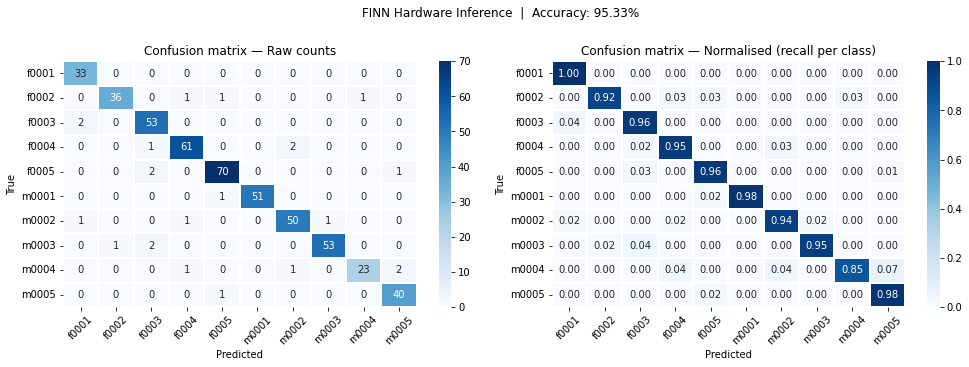

Saved: confusion_matrix.png

              precision    recall  f1-score   support

       f0001       0.92      1.00      0.96        33
       f0002       0.97      0.92      0.95        39
       f0003       0.91      0.96      0.94        55
       f0004       0.95      0.95      0.95        64
       f0005       0.96      0.96      0.96        73
       m0001       1.00      0.98      0.99        52
       m0002       0.94      0.94      0.94        53
       m0003       0.98      0.95      0.96        56
       m0004       0.96      0.85      0.90        27
       m0005       0.93      0.98      0.95        41

    accuracy                           0.95       493
   macro avg       0.95      0.95      0.95       493
weighted avg       0.95      0.95      0.95       493



In [7]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Raw counts', 'Normalised (recall per class)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.3, cbar=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion matrix — {title}')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'FINN Hardware Inference  |  Accuracy: {accuracy*100:.2f}%', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

print('\n' + classification_report(y_test, y_pred, target_names=CLASSES))

---
## 6. Summary

In [8]:
print('╔' + '═'*62 + '╗')
print('║' + ' FINN Speaker Recognition — KV260 Deployment Results'.center(62) + '║')
print('╚' + '═'*62 + '╝')
print(f'  Model          : {MODEL_WIDTH} MLP Fully Connected')
print(f'  Bitfile        : {BITFILE.name}')
print(f'  Channels       : {USE_CHANNELS} ({INPUT_CHANNELS} ch)')
print()
print(f'  Test-set accuracy                 : {accuracy*100:.2f}%')
print(f'  Mean latency per sample           : {latencies.mean():.3f} ms')
print(f'  Throughput                        : {1000/latencies.mean():.0f} samples/s')
print()
print('╚' + '═'*62 + '╝')

╔══════════════════════════════════════════════════════════════╗
║      FINN Speaker Recognition — KV260 Deployment Results     ║
╚══════════════════════════════════════════════════════════════╝
  Model          : 8-bits MLP Fully Connected
  Bitfile        : finn-accel.bit
  Channels       : I (1 ch)

  Test-set accuracy                 : 95.33%
  Mean latency per sample           : 2.871 ms
  Throughput                        : 348 samples/s

╚══════════════════════════════════════════════════════════════╝
